In [1]:
from langchain.messages import SystemMessage, HumanMessage
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_openai import ChatOpenAI
from langgraph.graph import StateGraph, START, END
from langchain_openai import ChatOpenAI
from pydantic import Field, BaseModel
from pathlib import Path
from dotenv import load_dotenv
from typing import TypedDict, List, Literal, Any
import requests
import json
import os

In [3]:
load_dotenv()

True

In [34]:
model = ChatGoogleGenerativeAI(
    model = "gemini-3.6-flash",
    api_key = os.getenv("GEMINI_API_KEY"),
    temperature = 0
)

model.invoke("Who is the president of India")

d:\LearnXYZ\learnenv\Lib\site-packages\langchain_google_genai\chat_models.py:3237: UserWarning: Model 'gemini-3.6-flash' uses fixed sampling defaults; the sampling parameter(s) temperature will be ignored.
  request = self._build_request_config(


AIMessage(content=[{'type': 'text', 'text': 'The President of India is **Droupadi Murmu**. \n\nShe took office on July 25, 2022, becoming the 15th President of India, as well as the first person from a tribal community and the second woman to hold the office.', 'extras': {'signature': 'ErgFCrUFARFNMg9UzF/XfQ/Svzh/DujW53rImBt31/r8gfiz85tuICt4C8Imh+JahxY3SzWtu8NyTodDDC4XdB+niBWqD4MW+RHrpim+ZiVQdcgTcCdkShVGiQyrxIo4oFok1uVK0lhs0Hnbyph0N4hmnwVxT45OM4toRQ/fgrjN5jq0S2nxeUk6d2Oi8bvrR+0dw6xqzHi6d1gtwvB/j7z2za1y3NXGkhWIKeEIfWA/QdOL1fdDvcIptx/RCCg1r/UhGdrwNM+7JUUSe5wGlUBdBzAwfT4dKYUoMYlmujEbUuTPlR9cBKcqaEqfUa1bR6nVAeWFWZp2rMN+Yo9zx2rFcJUn2FdxBYSQhHQNAxPwUFltP6kx9DZyqHa81BWGR2rpNz+/geKQuSun85hpodL2yIn2i2xqS9QhYF7yyLHrdcMizetVXXzKzoi3L8BdsZXMaK0PV1CUpt4nt+456pRG4/Yq5jaA1EdEZyipCHSqpfXOAE2piZGu3mrLJdmRD9b5XAOHm0NbX++oJgCMn95lnca4OvYrpoJ9bVRo4H6Ef10DEe53CkNTh1itUhysmmbMMn732ozetdFbernsQrwrgr1+N39a1FcCJdfoZO+7BZBOm7YiLZ/pcNYyxNHs0qtVX44FPweS6hmQNodXBO4+8eSBg/g7zrb/arq/FKXc2U9XUa776GbD2YfPq7+APco35RkHS

In [31]:
prompt = f"""You are an expert learning-roadmap generator.

Your task is to create a structured learning roadmap for any topic provided by the user.

The roadmap must organize the topic from foundational concepts to advanced concepts and should help a learner understand what they should learn and in what order.

Follow these rules:

1. Identify the major subtopics required to understand the given topic.
2. Arrange the subtopics in a logical learning sequence, generally from foundational concepts to advanced concepts.
3. For every subtopic:
   - Provide a clear subtopic name.
   - Assign a difficulty level: "Low", "Medium", or "High".
   - Give a moderate amount of description about the topic
   - Identify the important concepts/topics that should be learned within that subtopic.
4. For every topic inside a subtopic:
   - Provide a concise and meaningful topic name.
   - Give a moderate amount of description about the topic
   - Assign a difficulty level: "Low", "Medium", or "High".
   - generate a youtube video link for the topic (give only the links for the youtube videos that exists don't try to make up links else write focus on articles)
   - 2-3 articles for the topic
5. Include prerequisite concepts before concepts that depend on them.
6. Do not include unnecessary or highly specialized concepts unless they are important for understanding the topic.
7. The roadmap should be comprehensive enough for a learner to progress from beginner to advanced level.
8. Avoid duplicate topics.
9. Difficulty should represent the relative complexity of learning the concept, not its importance.
10. The number of subtopics and topics should depend on the complexity of the input topic. Do not use a fixed number.
11. Return only the structured output defined by the provided schema. Do not return explanations, Markdown, comments, or additional text.

The input will be a topic that the user wants to learn.

return only in json format

not any other format

Generate the learning roadmap for that topic."""

In [16]:
class SubjectState(TypedDict):
    topic: str
    roadmap: dict[str, Any]
    quiz: dict[str, Any]

In [35]:
class Topic(BaseModel):
    name: str
    difficulty: Literal["High", "Medium", "Low"]
    definition: str
    Links: str
    articles: List[str]

class Subtopic(BaseModel):
    subtopic_name: str
    difficulty: Literal["High", "Medium", "Low"]
    definition: str
    topics: List[Topic]

class MindMap(BaseModel):
    topic_name: str
    definition: str
    subtopics: List[Subtopic]

struct_model = model.with_structured_output(MindMap)

In [ ]:
class Question(BaseModel):
    question: str
    options: List[str]
    correct_answer: str
    explanation: str

class Quiz(BaseModel):
    questions: List[Question]

quiz_prompt = """You are an expert quiz generator.
Generate a multiple-choice quiz for the topic provided by the user.
By default, generate exactly 5 questions. If the user explicitly specifies a different number of questions in their topic prompt, generate exactly that many questions.

For each question:
- Provide the question text.
- Provide 4 options.
- Specify the exact correct answer (must match one of the options).
- Provide a short explanation of why the answer is correct."""

quiz_struct_model = model.with_structured_output(Quiz)

In [41]:
def roadmapnode(state: SubjectState):
    sysquery = SystemMessage(content=prompt)
    humquery = HumanMessage(content=state["topic"])
    query = [sysquery,humquery]

    response = struct_model.invoke(query)
    roadmap = response.model_dump()
    return {"roadmap": roadmap}

def quiznode(state: SubjectState):
    sysquery = SystemMessage(content=quiz_prompt)
    humquery = HumanMessage(content=state["topic"])
    query = [sysquery, humquery]

    response = quiz_struct_model.invoke(query)
    quiz = response.model_dump()
    return {"quiz": quiz}

def article(state: SubjectState):
    return

def youtube(state: SubjectState):
    return

def save_roadmap(state: SubjectState):

    path = Path("module.json")
    path.parent.mkdir(parents=True,exist_ok=True)

    if path.exists() and path.stat().st_size > 0:
        with open(path, "r", encoding="utf-8") as f:
            data = json.load(f)
    else:
        data = {}

    if state["topic"] not in data or not isinstance(data[state["topic"]], dict):
        data[state["topic"]] = {}
    
    if "roadmap" in state and state["roadmap"]:
        data[state["topic"]]["roadmap"] = state["roadmap"]
    if "quiz" in state and state["quiz"]:
        data[state["topic"]]["quiz"] = state["quiz"]

    with open(path, "w", encoding="utf-8") as f:
        json.dump(data, f, indent=4)

    return {}


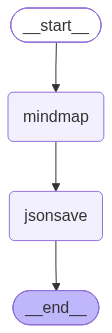

In [ ]:
#base model

graph = StateGraph(SubjectState)
graph.add_node("mindmap", roadmapnode)
graph.add_node("jsonsave", save_roadmap)
graph.add_edge(START, "mindmap")
graph.add_edge("mindmap", "jsonsave")
graph.add_edge("jsonsave", END)
graph.compile()

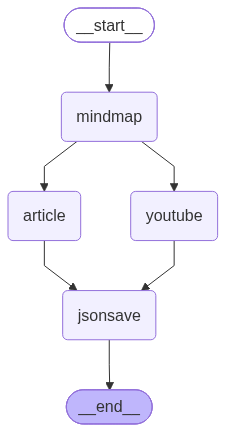

In [42]:
#updated model

graph = StateGraph(SubjectState)
graph.add_node("mindmap", roadmapnode)
graph.add_node("youtube", youtube)
graph.add_node("article", article)
graph.add_node("quiz", quiznode)
graph.add_node("jsonsave", save_roadmap)

graph.add_edge(START, "mindmap")
graph.add_edge("mindmap", "youtube")
graph.add_edge("mindmap", "article")
graph.add_edge("mindmap", "quiz")
graph.add_edge("article", "jsonsave")
graph.add_edge("youtube", "jsonsave")
graph.add_edge("quiz", "jsonsave")
graph.add_edge("jsonsave", END)
graph.compile()

In [38]:
workflow = graph.compile()
initial_state = {"topic": "Indian Medival history"}
final_state = workflow.invoke(initial_state)

d:\LearnXYZ\learnenv\Lib\site-packages\langchain_google_genai\chat_models.py:3237: UserWarning: Model 'gemini-3.6-flash' uses fixed sampling defaults; the sampling parameter(s) temperature will be ignored.
  request = self._build_request_config(


In [39]:
print(final_state["roadmap"])

{'topic_name': 'Indian Medieval History', 'definition': 'Indian Medieval History covers the period from the decline of the Gupta Empire and the rise of regional kingdoms around the 8th century CE to the fall of the Mughal Empire in the 18th century CE, marking significant political, cultural, and socio-economic transformations.', 'subtopics': [{'subtopic_name': 'Early Medieval India (c. 750 - 1200 CE)', 'difficulty': 'Low', 'definition': 'This era marks the rise of powerful regional dynasties across North and South India, characterising political decentralization, feudalism, and rich temple architecture development.', 'topics': [{'name': 'Tripartite Struggle and North Indian Kingdoms', 'difficulty': 'Medium', 'definition': 'Explores the prolonged conflict between the Palas, Pratiharas, and Rashtrakutas for control over the strategic region of Kannauj.', 'Links': 'https://www.youtube.com/watch?v=Xn4gN-4x36k', 'articles': ['https://www.britannica.com/place/India/The-tripartite-struggle',

In [ ]:
import json
print(json.dumps(final_state.get("quiz", {}), indent=2))